In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skimage.io as io
import tifffile
from cellpose import core, models, utils

use_GPU = core.use_gpu()

In [ ]:
image_path = pathlib.Path("../processed_data/raw_z_input/nuclei_masks.tiff").resolve(
    strict=True
)
# image_path = pathlib.Path("../examples/raw_z_input/C6-1_405.tif")
# read the image
data = tifffile.imread(image_path)
print(data.shape)
model = models.Cellpose(model_type="nuclei", gpu=use_GPU)

(35, 1537, 1540)


/home/lippincm/miniforge3/envs/GFF_cellpose/lib/python3.9/site-packages/cellpose/resnet_torch.py:271: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f

In [3]:
channels = [[0, 0]]
masks, flows, styles, diams = model.eval(
    data,
    diameter=80,
    z_axis=0,
    channels=channels,
    do_3D=True,
    # stitch_threshold=0.9,
    anisotropy=10,
    augment=False,
)

In [4]:
# save the masks to a file to read later in napari
masks_path = pathlib.Path("../processed_data/raw_z_input/nuclei_masks_3D.tiff")
tifffile.imsave(masks_path, masks.astype(np.uint16))

/tmp/ipykernel_1365024/3111372839.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(masks_path, masks.astype(np.uint16))


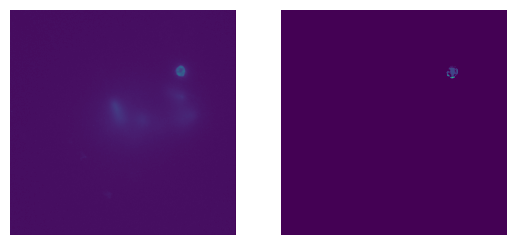

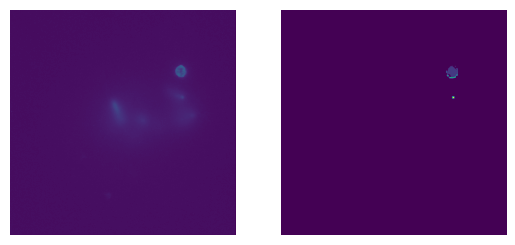

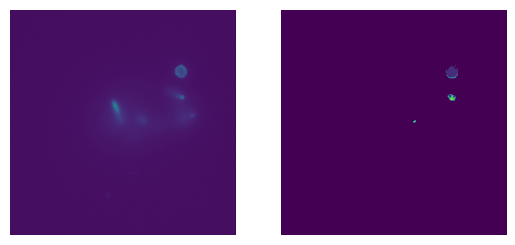

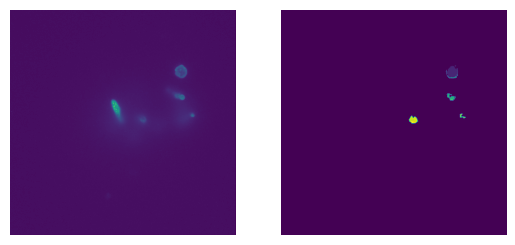

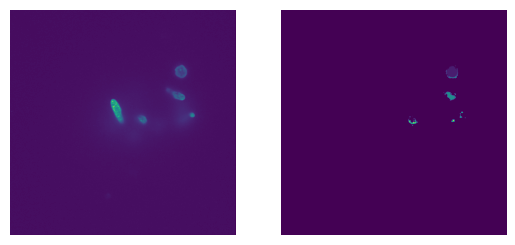

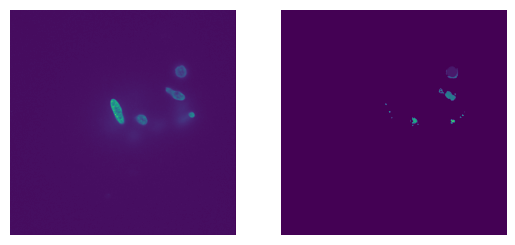

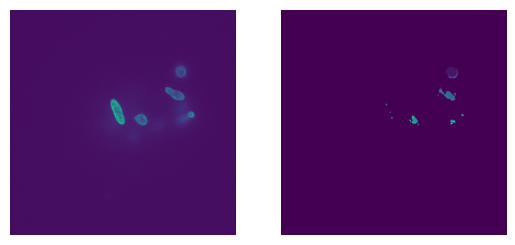

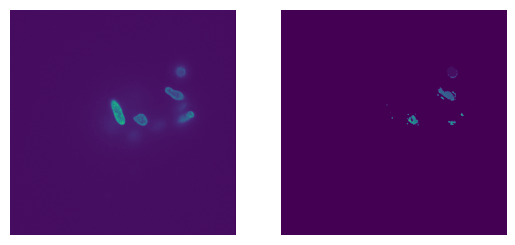

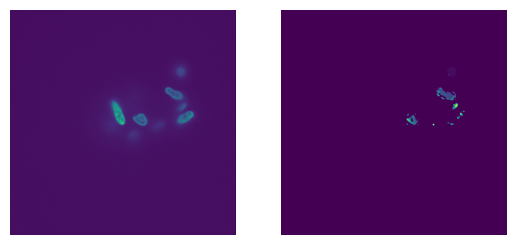

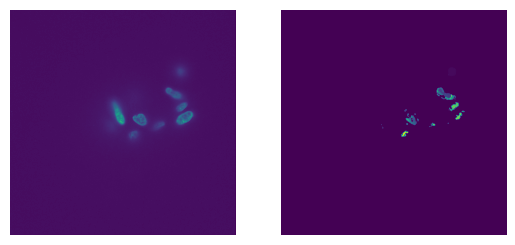

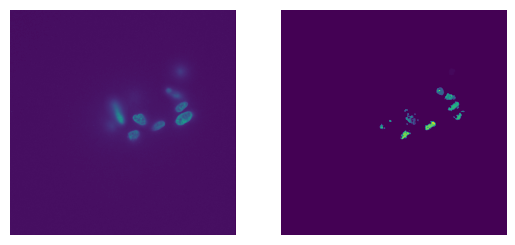

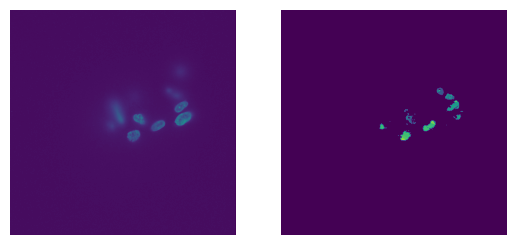

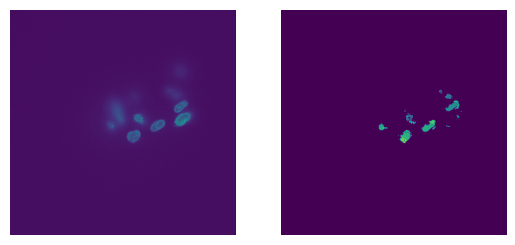

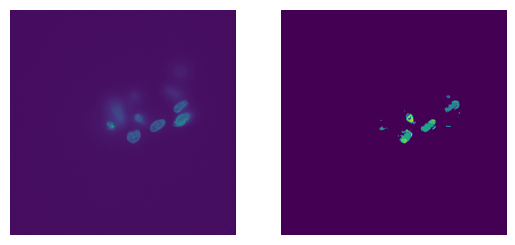

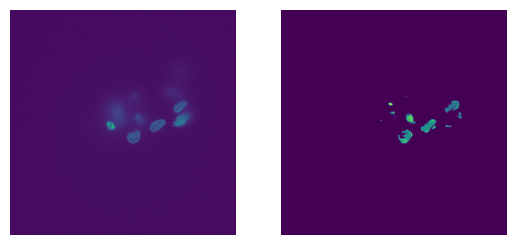

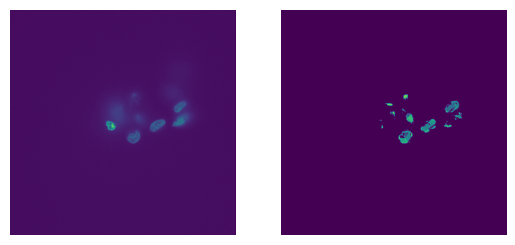

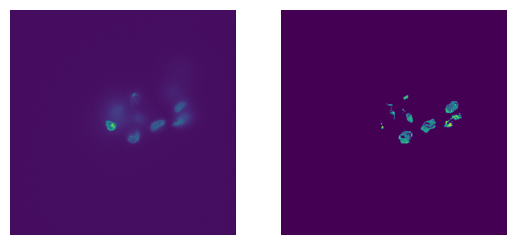

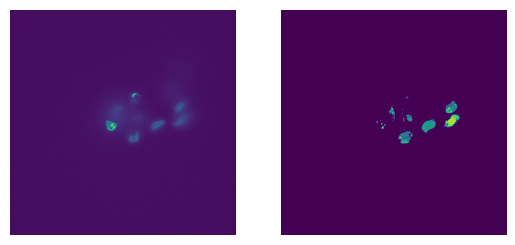

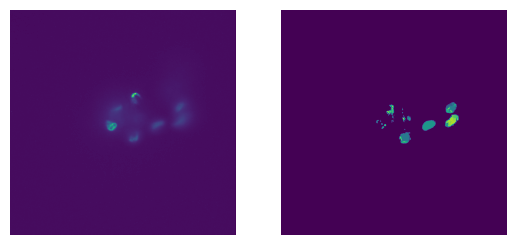

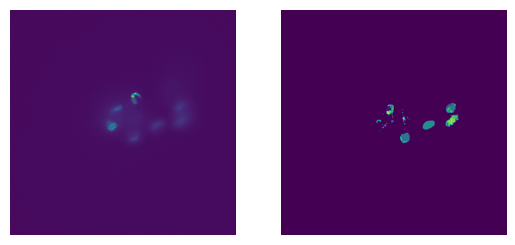

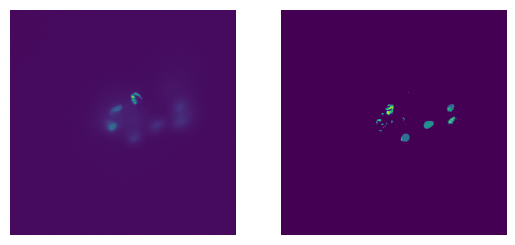

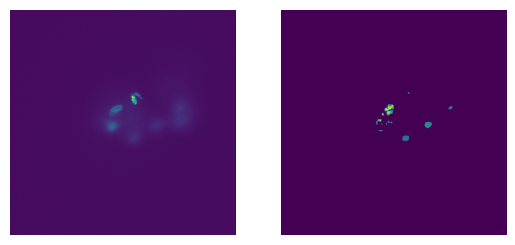

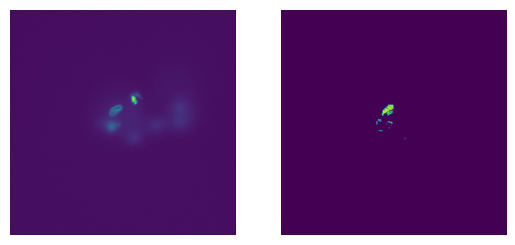

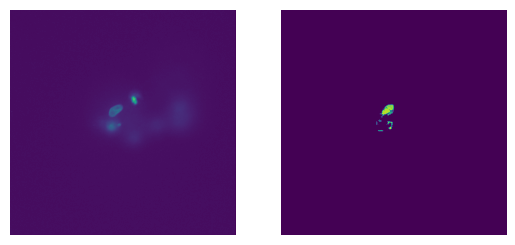

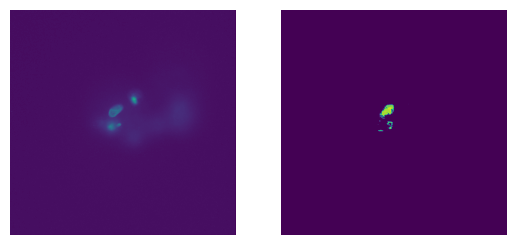

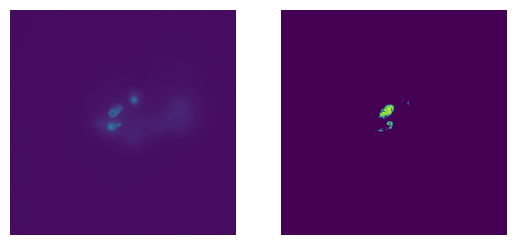

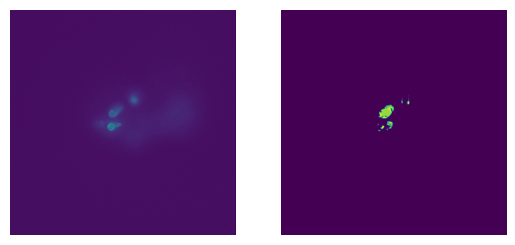

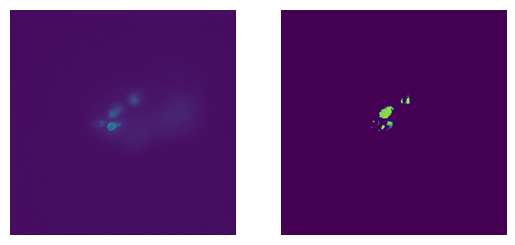

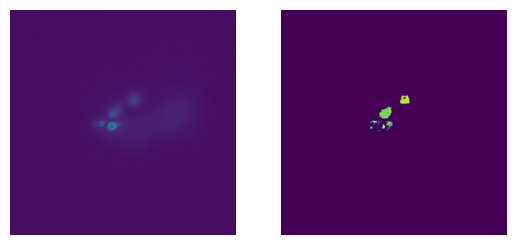

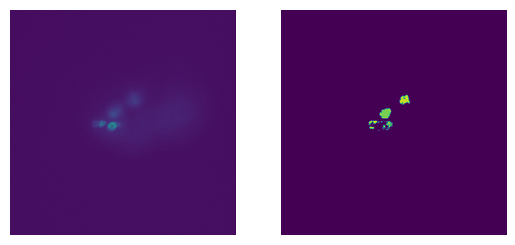

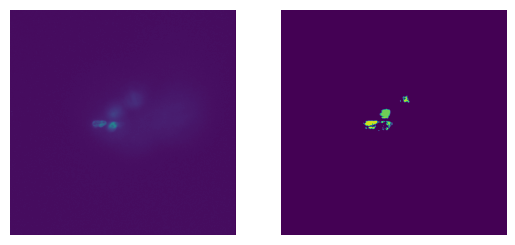

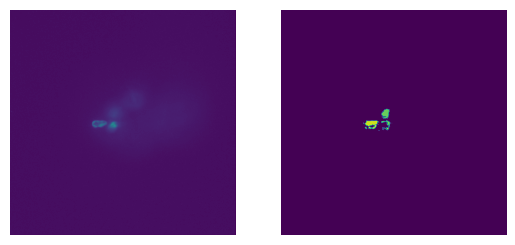

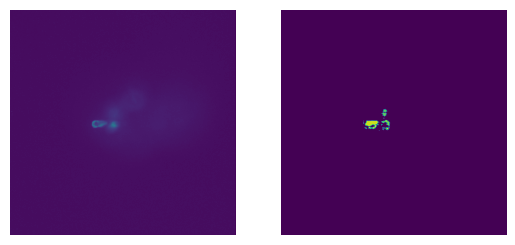

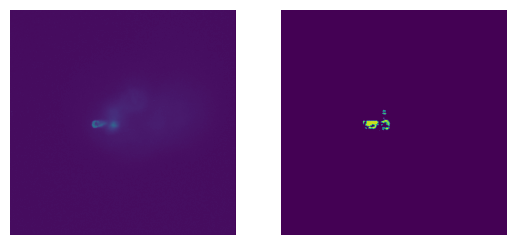

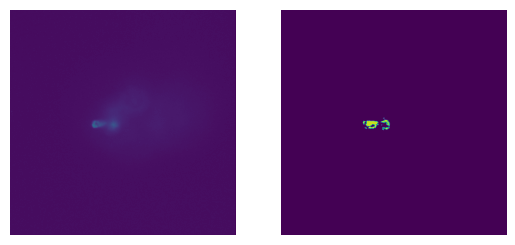

In [5]:
# visualize the masks
for i in range(len(masks)):
    plt.subplot(1, 2, 1)
    plt.imshow(data[i])
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(masks[i])
    plt.axis("off")
    plt.show()